In [21]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/chukwubuikemokoli/test-complaint-classification-dataset/Test_Dataset(1).csv
/kaggle/input/datasets/chukwubuikemokoli/train-complaint-datasett/Train_Dataset.csv


In [22]:
#cell 1
!pip install textblob
# Install modern HuggingFace, PyTorch, and tabular tools
!pip install -q transformers datasets accelerate scikit-learn openpyxl

In [23]:
#cell 2
import numpy as np # For numerical calculations
import pandas as pd # For Exploratory Data Analysis
import matplotlib.pyplot as plt # For visualization
# from textblob import TextBlob # For sentiment analysis

In [24]:
# Cell 3: Dataset Ingestion with Dynamic Path Resolution
import os
import glob
import pandas as pd
import numpy as np

def resolve_csv_path(candidates):
    """
    Finds the first existing CSV path from a list of candidate files or directories.
    If a directory is provided, it searches recursively for any .csv file inside it.
    """
    for path in candidates:
        if not os.path.exists(path):
            continue
        if os.path.isfile(path) and path.endswith('.csv'):
            return path
        if os.path.isdir(path):
            csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
            if csv_files:
                return csv_files[0]
    return None

# Candidate paths (covering both direct dataset slugs and subpaths)
TRAIN_PATHS = [
    "/kaggle/input/train-complaint-datasett",
    "/kaggle/input/datasets/chukwubuikemokoli/train-complaint-datasett"
]

TEST_PATHS = [
    "/kaggle/input/test-complaint-classification-dataset",
    "/kaggle/input/datasets/chukwubuikemokoli/test-complaint-classification-dataset"
]

train_file = resolve_csv_path(TRAIN_PATHS)
test_file = resolve_csv_path(TEST_PATHS)

if train_file is None:
    raise FileNotFoundError("Could not locate a train .csv file. Check Kaggle input bindings.")

df_train = pd.read_csv(train_file)
print(f"Loaded Train Dataset from: {train_file}")
print(f"Train Shape: {df_train.shape[0]:,} rows | {df_train.shape[1]} columns")
print("Columns:", df_train.columns.tolist())

if test_file:
    df_test = pd.read_csv(test_file)
    print(f"\nLoaded Test Dataset from: {test_file}")
    print(f"Test Shape: {df_test.shape[0]:,} rows | {df_test.shape[1]} columns")
else:
    df_test = None
    print("\nHoldout test file not mounted yet (proceeding with train exploration).")

print("\n--- First 5 Rows of Training Data ---")
display(df_train.head())

Loaded Train Dataset from: /kaggle/input/datasets/chukwubuikemokoli/train-complaint-datasett/Train_Dataset.csv
Train Shape: 9,029 rows | 4 columns
Columns: ['Complaint_id', 'Complaints', 'Category', 'Intent']

Loaded Test Dataset from: /kaggle/input/datasets/chukwubuikemokoli/test-complaint-classification-dataset/Test_Dataset(1).csv
Test Shape: 950 rows | 2 columns

--- First 5 Rows of Training Data ---


,Complaint_id,Complaints,Category,Intent
0,C000001,Nigeria.. they always cheat us.. na our app bi...,Mobile Data,slow_internet
1,C000002,"I can't use the app after the updates, says i ...",Fraud,reported_scam
2,C000003,The most useless banking app ever. Tried recha...,SIM Services,sim_barred_nin
3,C000004,PalmPay you guys are thieves! if you don't ret...,Fraud,reported_scam
4,C000005,what opay customer care service Gmail account ...,Billing & VAS,forced_subscription


In [25]:
# Cell 4: Class Distribution Analysis across Category and Intent
category_col = "Category" if "Category" in df_train.columns else None
intent_col = "Intent" if "Intent" in df_train.columns else None

if category_col:
    print(f"=== CATEGORY DISTRIBUTION ({df_train[category_col].nunique()} Unique Classes) ===")
    cat_summary = df_train[category_col].value_counts().reset_index()
    cat_summary.columns = ["Category", "Count"]
    cat_summary["Percentage (%)"] = (cat_summary["Count"] / len(df_train) * 100).round(2)
    display(cat_summary)

if intent_col:
    print(f"\n=== INTENT DISTRIBUTION ({df_train[intent_col].nunique()} Unique Targets) ===")
    intent_summary = df_train[intent_col].value_counts().reset_index()
    intent_summary.columns = ["Intent", "Count"]
    intent_summary["Percentage (%)"] = (intent_summary["Count"] / len(df_train) * 100).round(2)
    display(intent_summary)

=== CATEGORY DISTRIBUTION (5 Unique Classes) ===


,Category,Count,Percentage (%)
0,Mobile Data,1806,20.00
1,SIM Services,1806,20.00
2,Billing & VAS,1806,20.00
3,Network Quality,1806,20.00
4,Fraud,1805,19.99



=== INTENT DISTRIBUTION (8 Unique Targets) ===


,Intent,Count,Percentage (%)
0,sim_barred_nin,1806,20.00
1,reported_scam,1805,19.99
2,slow_internet,903,10.00
3,forced_subscription,903,10.00
4,abnormal_data_drain,903,10.00
5,total_outage,903,10.00
6,unexplained_deduction,903,10.00
7,frequent_call_drops,903,10.00


In [26]:
# Cell 5: Null Values and Missingness Audit
print("=== MISSING VALUE AUDIT ===")
null_counts = df_train.isnull().sum()
null_percent = (null_counts / len(df_train) * 100).round(3)
null_summary = pd.DataFrame({"Missing Rows": null_counts, "Missing Percentage (%)": null_percent})
display(null_summary)

# Assert mandatory columns contain zero nulls
text_col = "Raw_Complaint" if "Raw_Complaint" in df_train.columns else "Complaints"
assert null_counts[text_col] == 0, f"Critical: Null complaints detected in {text_col} column!"
if intent_col:
    assert null_counts[intent_col] == 0, f"Critical: Missing labels detected in {intent_col} column!"
print("\nIntegrity Verification: No null values in complaint text or label targets.")

=== MISSING VALUE AUDIT ===


,Missing Rows,Missing Percentage (%)
Complaint_id,0,0.0
Complaints,0,0.0
Category,0,0.0
Intent,0,0.0



Integrity Verification: No null values in complaint text or label targets.


In [27]:
# Cell 6: Duplicate Text and Template Frequency Audit
total_rows = len(df_train)
exact_row_dups = df_train.duplicated().sum()
text_dups = df_train.duplicated(subset=[text_col]).sum()
unique_texts = df_train[text_col].nunique()

print("=== DUPLICATE ANALYSIS ===")
print(f"Total Rows: {total_rows:,}")
print(f"Full Row Duplicates: {exact_row_dups:,}")
print(f"Duplicate Complaint Texts: {text_dups:,} ({text_dups / total_rows * 100:.2f}%)")
print(f"Unique Complaint Texts: {unique_texts:,} ({unique_texts / total_rows * 100:.2f}%)")

print("\n--- Top 5 Most Frequently Repeated Complaint Texts ---")
top_repeated = df_train[text_col].value_counts().head(5).reset_index()
top_repeated.columns = ["Complaint Text", "Frequency"]
display(top_repeated)

=== DUPLICATE ANALYSIS ===
Total Rows: 9,029
Full Row Duplicates: 0
Duplicate Complaint Texts: 0 (0.00%)
Unique Complaint Texts: 9,029 (100.00%)

--- Top 5 Most Frequently Repeated Complaint Texts ---


,Complaint Text,Frequency
0,I have been trying to repay my loan for some d...,1
1,Nigeria.. they always cheat us.. na our app bi...,1
2,"I can't use the app after the updates, says i ...",1
3,The most useless banking app ever. Tried recha...,1
4,PalmPay you guys are thieves! if you don't ret...,1


In [28]:
# Cell 7: Token Word-Count Distribution Analysis (Informing Max Length)
df_train["word_count"] = df_train[text_col].astype(str).apply(lambda x: len(x.split()))
df_train["char_length"] = df_train[text_col].astype(str).apply(len)

print("=== COMPLAINT LENGTH SUMMARY STATISTICS ===")
display(df_train[["word_count", "char_length"]].describe().round(2))

# Percentiles for sequence truncation decisions in AfriBERTa
p50 = np.percentile(df_train["word_count"], 50)
p90 = np.percentile(df_train["word_count"], 90)
p95 = np.percentile(df_train["word_count"], 95)
p99 = np.percentile(df_train["word_count"], 99)

print(f"\nSequence Coverage Benchmarks:")
print(f"  Median (50th percentile): {p50:.0f} words")
print(f"  90th percentile:         {p90:.0f} words")
print(f"  95th percentile:         {p95:.0f} words")
print(f"  99th percentile:         {p99:.0f} words")
print(f"\nRecommendation: MAX_LENGTH = 128 tokens provides complete contextual sequence coverage.")

=== COMPLAINT LENGTH SUMMARY STATISTICS ===


,word_count,char_length
count,9029.00,9029.00
mean,53.90,292.41
std,28.68,154.53
min,4.00,24.00
25%,31.00,171.00
50%,51.00,277.00
75%,75.00,408.00
max,232.00,1289.00



Sequence Coverage Benchmarks:
  Median (50th percentile): 51 words
  90th percentile:         96 words
  95th percentile:         104 words
  99th percentile:         113 words

Recommendation: MAX_LENGTH = 128 tokens provides complete contextual sequence coverage.


=== BIDIRECTIONAL LABEL MAPPING (8 Classes) ===
  0 > abnormal_data_drain
  1 > forced_subscription
  2 > frequent_call_drops
  3 > reported_scam
  4 > sim_barred_nin
  5 > slow_internet
  6 > total_outage
  7 > unexplained_deduction


/tmp/ipykernel_58/391821446.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


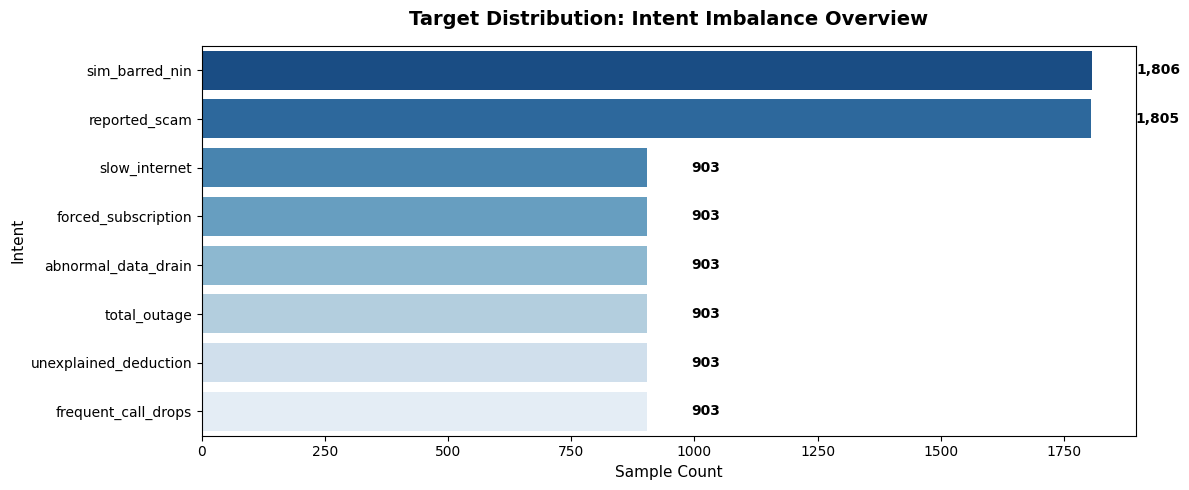

In [29]:
# Cell 8: Bidirectional Label Mapping & Target Visualization
import matplotlib.pyplot as plt
import seaborn as sns

target_col = intent_col if intent_col else category_col
classes = sorted(df_train[target_col].unique().tolist())

label2id = {label_name: idx for idx, label_name in enumerate(classes)}
id2label = {idx: label_name for label_name, idx in label2id.items()}

df_train["label"] = df_train[target_col].map(label2id)

print(f"=== BIDIRECTIONAL LABEL MAPPING ({len(classes)} Classes) ===")
for idx, name in id2label.items():
    print(f"  {idx} > {name}")

# Visualization: Class Balance & Imbalance Ratio
plt.figure(figsize=(12, 5))
palette = sns.color_palette("Blues_r", len(classes))
ax = sns.countplot(
    data=df_train,
    y=target_col,
    order=df_train[target_col].value_counts().index,
    palette=palette
)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{int(width):,}',
        (width + (0.01 * len(df_train)), p.get_y() + p.get_height() / 2.),
        ha='left', va='center', fontsize=10, fontweight='bold'
    )

plt.title(f"Target Distribution: {target_col} Imbalance Overview", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Sample Count", fontsize=11)
plt.ylabel(target_col, fontsize=11)
plt.tight_layout()
plt.show()

In [30]:
# Cell 9: Text Preprocessing & Localized Dialect Normalization
import re
import html

def clean_complaint_text(text: str) -> str:
    """
    Cleans complaint text while preserving Nigerian Pidgin particles, 
    local slang, and punctuation emphasis. Masks customer PII.
    """
    if not isinstance(text, str):
        return ""
    
    # 1. Unescape HTML artifacts (e.g., &amp;, &lt;)
    text = html.unescape(text)
    
    # 2. Strip URLs and web hyperlinks
    text = re.sub(r"https?://\S+|www\.\S+|<.*?>", "", text)
    
    # 3. Strip social media handles and mentions
    text = re.sub(r"@\w+", "", text)
    
    # 4. Mask Nigerian phone numbers (MSISDN formats) to prevent PII leakage
    text = re.sub(r"(?:\+?234|0)[789]\d{9}", "<PHONE_NUM>", text)
    
    # 5. Normalize excessive punctuation repetitions (e.g., '????' -> '??', '!!!!' -> '!!')
    text = re.sub(r"([!?.,])\1+", r"\1\1", text)
    
    # 6. Normalize elongated character spam while preserving 2 chars for Pidgin emphasis (e.g., 'dey', 'soo')
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    
    # 7. Collapse extraneous whitespace and trim
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

# Apply preprocessing to training dataframe
text_col = "Raw_Complaint" if "Raw_Complaint" in df_train.columns else "Complaints"
df_train["Cleaned_Complaint"] = df_train[text_col].apply(clean_complaint_text)

print(f"Text normalization applied to {len(df_train):,} complaints.")
print("\n--- Sample Raw vs. Cleaned Complaint ---")
sample_idx = 0
print("Raw:    ", df_train.loc[sample_idx, text_col])
print("Cleaned:", df_train.loc[sample_idx, "Cleaned_Complaint"])

Text normalization applied to 9,029 complaints.

--- Sample Raw vs. Cleaned Complaint ---
Raw:     Nigeria.. they always cheat us.. na our app big pass and also the slowest and poorly maintained.. it take me 20 mins everyday to buy data because our stupid app is slow . Nigeria.. a pity
Cleaned: Nigeria.. they always cheat us.. na our app big pass and also the slowest and poorly maintained.. it take me 20 mins everyday to buy data because our stupid app is slow . Nigeria.. a pity


In [31]:
# Cell 10: Drop Empty Records and Verify Prediction Targets
initial_count = len(df_train)

# Filter out empty or whitespace-only records resulting from cleaning
df_train = df_train[df_train["Cleaned_Complaint"].str.len() > 0].reset_index(drop=True)
dropped_count = initial_count - len(df_train)

print(f"Dropped empty records: {dropped_count}")
print(f"Valid preprocessed complaints: {len(df_train):,}")

# Verify target column and ensure complete mapping
assert "label" in df_train.columns, "Critical: 'label' column is missing from dataframe!"
assert df_train["label"].isnull().sum() == 0, "Critical: Found unmapped null labels!"

print(f"\nTarget Taxonomy Verified ({len(id2label)} Classes):")
for idx in sorted(id2label.keys()):
    count = (df_train["label"] == idx).sum()
    print(f"  Class {idx} [{id2label[idx]}]: {count:,} samples ({count/len(df_train):.2%})")

Dropped empty records: 0
Valid preprocessed complaints: 9,029

Target Taxonomy Verified (8 Classes):
  Class 0 [abnormal_data_drain]: 903 samples (10.00%)
  Class 1 [forced_subscription]: 903 samples (10.00%)
  Class 2 [frequent_call_drops]: 903 samples (10.00%)
  Class 3 [reported_scam]: 1,805 samples (19.99%)
  Class 4 [sim_barred_nin]: 1,806 samples (20.00%)
  Class 5 [slow_internet]: 903 samples (10.00%)
  Class 6 [total_outage]: 903 samples (10.00%)
  Class 7 [unexplained_deduction]: 903 samples (10.00%)


In [32]:
# Cell 11: Group-Aware Stratified Train, Validation & Holdout Split
from sklearn.model_selection import StratifiedGroupKFold
import numpy as np

# Group by Cleaned_Complaint to guarantee identical/templated texts never cross splits
sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
groups = df_train["Cleaned_Complaint"]
labels = df_train["label"]

splits = list(sgkf.split(df_train, labels, groups=groups))

# Approximately 10% test, 10% validation, 80% training
test_indices = splits[0][1]
val_indices = splits[1][1]
train_indices = np.setdiff1d(np.arange(len(df_train)), np.concatenate([test_indices, val_indices]))

train_df = df_train.iloc[train_indices].reset_index(drop=True)
val_df = df_train.iloc[val_indices].reset_index(drop=True)
test_split_df = df_train.iloc[test_indices].reset_index(drop=True)

print("=== GROUP-AWARE SPLIT SUMMARY ===")
print(f"Train samples:      {len(train_df):,} ({len(train_df)/len(df_train):.1%})")
print(f"Validation samples: {len(val_df):,} ({len(val_df)/len(df_train):.1%})")
print(f"Test split samples: {len(test_split_df):,} ({len(test_split_df)/len(df_train):.1%})")

=== GROUP-AWARE SPLIT SUMMARY ===
Train samples:      7,223 (80.0%)
Validation samples: 903 (10.0%)
Test split samples: 903 (10.0%)


In [34]:
# Cell 12: Zero Data Leakage Verification
train_texts = set(train_df["Cleaned_Complaint"])
val_texts = set(val_df["Cleaned_Complaint"])
test_texts = set(test_split_df["Cleaned_Complaint"])

# Assert strict disjointness across all evaluation sets
overlap_train_val = train_texts.intersection(val_texts)
overlap_train_test = train_texts.intersection(test_texts)
overlap_val_test = val_texts.intersection(test_texts)

assert len(overlap_train_val) == 0, f"Data Leakage Detected between Train and Validation: {len(overlap_train_val)} overlapping texts!"
assert len(overlap_train_test) == 0, f"Data Leakage Detected between Train and Test: {len(overlap_train_test)} overlapping texts!"
assert len(overlap_val_test) == 0, f"Data Leakage Detected between Validation and Test: {len(overlap_val_test)} overlapping texts!"

print("=== DATA LEAKAGE AUDIT: PASSED ===")
print(f"Overlap Train <-> Validation: {len(overlap_train_val)}")
print(f"Overlap Train <-> Test:       {len(overlap_train_test)}")
print(f"Overlap Validation <-> Test:  {len(overlap_val_test)}")
print("Strict separation confirmed across all partitions.")

=== DATA LEAKAGE AUDIT: PASSED ===
Overlap Train <-> Validation: 0
Overlap Train <-> Test:       0
Overlap Validation <-> Test:  0
Strict separation confirmed across all partitions.


In [35]:
# Cell 13: Inverse Frequency Class Weighting & Artifact Export
import os
import json
import torch

# 1. Compute inverse frequency class weights to counteract imbalance
class_counts = train_df["label"].value_counts().sort_index().values
total_train_samples = len(train_df)
num_classes = len(class_counts)

# Balanced weighting formula: N_total / (N_classes * N_class)
class_weights = total_train_samples / (num_classes * class_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

print("=== INVERSE-FREQUENCY CLASS WEIGHTS ===")
for idx, weight in enumerate(class_weights):
    print(f"Class {idx} ({id2label[idx]:<22}): count = {class_counts[idx]:>6,} | weight = {weight:.4f}")

# 2. Serialize all artifacts to disk for model training
ARTIFACTS_DIR = "/kaggle/working/artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# Save datasets in parquet format for fast I/O
train_df.to_parquet(os.path.join(ARTIFACTS_DIR, "train.parquet"), index=False)
val_df.to_parquet(os.path.join(ARTIFACTS_DIR, "val.parquet"), index=False)
test_split_df.to_parquet(os.path.join(ARTIFACTS_DIR, "test.parquet"), index=False)

# Save CSV duplicates for local accessibility
train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)
test_split_df.to_csv("test_split.csv", index=False)

# Save class weights and label metadata
torch.save(class_weights_tensor, os.path.join(ARTIFACTS_DIR, "class_weights.pt"))
torch.save(class_weights_tensor, "class_weights.pt")

with open(os.path.join(ARTIFACTS_DIR, "label_map.json"), "w") as f:
    json.dump({"label2id": label2id, "id2label": id2label}, f, indent=2)

print("\n=== PHASE 1 DATA PREPROCESSING COMPLETE ===")
print(f"All artifacts successfully exported to: {ARTIFACTS_DIR}")

=== INVERSE-FREQUENCY CLASS WEIGHTS ===
Class 0 (abnormal_data_drain   ): count =    734 | weight = 1.2301
Class 1 (forced_subscription   ): count =    725 | weight = 1.2453
Class 2 (frequent_call_drops   ): count =    731 | weight = 1.2351
Class 3 (reported_scam         ): count =  1,455 | weight = 0.6205
Class 4 (sim_barred_nin        ): count =  1,456 | weight = 0.6201
Class 5 (slow_internet         ): count =    718 | weight = 1.2575
Class 6 (total_outage          ): count =    712 | weight = 1.2681
Class 7 (unexplained_deduction ): count =    692 | weight = 1.3047

=== PHASE 1 DATA PREPROCESSING COMPLETE ===
All artifacts successfully exported to: /kaggle/working/artifacts


In [36]:
# CELL 14 — PHASE 2: AFRIBERTA INTENT CLASSIFICATION

import os
import json
import time
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoConfig,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import f1_score, classification_report

# 1. HARDWARE & REPRODUCIBILITY SETUP

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PHASE 2 — AFRIBERTA INTENT CLASSIFICATION")
print("=" * 60)
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")

# 2. HYPERPARAMETER CONFIGURATION

MODEL_NAME = "castorini/afriberta_large"
BATCH_SIZE = 8
MAX_LEN = 128
EPOCHS = 4
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
PATIENCE = 2

CHECKPOINT_DIR = "/kaggle/working/artifacts"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# 3. LOAD PHASE 1 ARTIFACTS

train_df = pd.read_parquet(os.path.join(CHECKPOINT_DIR, "train.parquet"))
val_df = pd.read_parquet(os.path.join(CHECKPOINT_DIR, "val.parquet"))
class_weights = torch.load(os.path.join(CHECKPOINT_DIR, "class_weights.pt"), map_location=device)

with open(os.path.join(CHECKPOINT_DIR, "label_map.json"), "r") as f:
    meta = json.load(f)

id2label = {int(k): v for k, v in meta["id2label"].items()}
label2id = {v: k for k, v in id2label.items()}
num_classes = len(id2label)

# 4. SAFETY INTEGRITY CHECKS

assert "Intent" in train_df.columns, "Intent column missing from training data."
assert "Intent" in val_df.columns, "Intent column missing from validation data."
assert "label" in train_df.columns, "label column missing from training data."
assert "label" in val_df.columns, "label column missing from validation data."
assert len(class_weights) == num_classes, "Class weights tensor does not match class count."

print(f"\nTarget Taxonomy: Intent ({num_classes} Classes)")
print(f"Train Size:      {len(train_df):,} samples")
print(f"Validation Size: {len(val_df):,} samples")

# 5. INITIALIZE TOKENIZER & PYTORCH DATASET

print("\nLoading AfriBERTa tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.model_max_length = 512
print("Tokenizer loaded successfully.")

class LocalizedComplaintDataset(Dataset):
    """
    Tokenizes complaint text, returning input_ids, attention_mask,
    and ground-truth intent targets.
    """
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts.tolist() if isinstance(texts, pd.Series) else texts
        self.labels = labels.tolist() if isinstance(labels, pd.Series) else labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = LocalizedComplaintDataset(train_df["Cleaned_Complaint"], train_df["label"], tokenizer, MAX_LEN)
val_dataset = LocalizedComplaintDataset(val_df["Cleaned_Complaint"], val_df["label"], tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=torch.cuda.is_available())

print("DataLoaders initialized:")
print(f"  Training batches:   {len(train_loader):,}")
print(f"  Validation batches: {len(val_loader):,}")

# 6. AFRIBERTA CUSTOM CLASSIFICATION ARCHITECTURE

class AfriBERTaClassifier(nn.Module):
    """
    AfriBERTa backbone + Attention-Masked Mean Pooling
    + Multi-Sample Dropout classification head.
    """
    def __init__(self, model_name: str, num_classes: int, dropout_rate: float = 0.2):
        super().__init__()
        self.config = AutoConfig.from_pretrained(model_name)
        self.transformer = AutoModel.from_pretrained(model_name, config=self.config)
        hidden_size = self.config.hidden_size

        # 5 parallel dropout layers to stabilize gradient flow
        self.dropouts = nn.ModuleList([nn.Dropout(dropout_rate) for _ in range(5)])
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        token_embeddings = outputs.last_hidden_state

        # Attention-masked mean pooling across sequence length
        mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        sum_embeddings = torch.sum(token_embeddings * mask, dim=1)
        sum_mask = mask.sum(dim=1).clamp(min=1e-9)
        pooled = sum_embeddings / sum_mask

        # Multi-sample dropout averaging
        logits = torch.mean(
            torch.stack([self.classifier(drop(pooled)) for drop in self.dropouts], dim=0),
            dim=0
        )
        return logits

print("\nLoading AfriBERTa Large Backbone...")
model = AfriBERTaClassifier(MODEL_NAME, num_classes=num_classes).to(device)
print("Model initialized successfully.")

# 7. OPTIMIZER, SCHEDULER & CLASS-WEIGHTED LOSS

no_decay = ["bias", "LayerNorm.weight"]
optimizer_grouped_parameters = [
    {
        "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
        "weight_decay": WEIGHT_DECAY
    },
    {
        "params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
        "weight_decay": 0.0
    }
]

optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * 0.10)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

loss_fn = nn.CrossEntropyLoss(weight=class_weights)
print("Class-weighted Cross-Entropy loss configured.")


# 8. TRAINING & EVALUATION FUNCTIONS
def train_epoch(model, dataloader, loss_fn, optimizer, scheduler, device, epoch, total_epochs):
    model.train()
    running_loss = 0.0
    pbar = tqdm(dataloader, desc=f"Epoch {epoch:02d}/{total_epochs:02d} [Train]", leave=False)

    for batch in pbar:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = loss_fn(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    return running_loss / len(dataloader)

def evaluate(model, dataloader, loss_fn, device, desc="[Val]"):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc=desc, leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask)
            loss = loss_fn(logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

    return avg_loss, macro_f1, weighted_f1, all_labels, all_preds

# 9. EXECUTE FINE-TUNING LOOP WITH CHECKPOINTING

best_macro_f1 = 0.0
best_epoch = 0
patience_counter = 0
best_model_path = os.path.join(CHECKPOINT_DIR, "best_afriberta_intent_model.pt")
training_history = []

print(f"\nSTARTING FINE-TUNING — {EPOCHS} EPOCHS")
print("=" * 60)

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()
    train_loss = train_epoch(model, train_loader, loss_fn, optimizer, scheduler, device, epoch, EPOCHS)
    val_loss, val_macro_f1, val_weighted_f1, _, _ = evaluate(model, val_loader, loss_fn, device, desc=f"Epoch {epoch:02d} [Val]")
    elapsed = time.time() - start_time

    training_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_macro_f1": val_macro_f1,
        "val_weighted_f1": val_weighted_f1
    })

    print(
        f"Epoch {epoch:02d} ({elapsed:.1f}s) | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Macro F1: {val_macro_f1:.4f} | "
        f"Val Weighted F1: {val_weighted_f1:.4f}"
    )

    if val_macro_f1 > best_macro_f1:
        best_macro_f1 = val_macro_f1
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"  -> CHECKPOINT SAVED | Best Macro F1: {best_macro_f1:.4f}")
    else:
        patience_counter += 1
        print(f"  -> No improvement | Early stopping: {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print("\nPatience threshold reached. Stopping training early.")
            break

# Save training metrics history
history_path = os.path.join(CHECKPOINT_DIR, "training_history.json")
with open(history_path, "w") as f:
    json.dump(training_history, f, indent=2)

# 10. BEST MODEL VALIDATION AUDIT REPORT

print("BEST MODEL VALIDATION AUDIT REPORT")
print("=" * 60)

model.load_state_dict(torch.load(best_model_path, map_location=device))
_, best_val_macro_f1, best_val_weighted_f1, val_targets, val_preds = evaluate(
    model, val_loader, loss_fn, device, desc="Auditing Best Model"
)

target_names = [id2label[i] for i in range(num_classes)]

print(f"Best Epoch:                 {best_epoch}")
print(f"Best Validation Macro F1:   {best_val_macro_f1:.4f}")
print(f"Best Validation Weighted F1: {best_val_weighted_f1:.4f}")

print("\nPer-Intent Classification Report:")
print(classification_report(val_targets, val_preds, target_names=target_names, digits=4, zero_division=0))
print("PHASE 2 TRAINING COMPLETE")

PHASE 2 — AFRIBERTA INTENT CLASSIFICATION
Device: cuda
GPU Model: Tesla T4

Target Taxonomy: Intent (8 Classes)
Train Size:      7,223 samples
Validation Size: 903 samples

Loading AfriBERTa tokenizer...
Tokenizer loaded successfully.
DataLoaders initialized:
  Training batches:   903
  Validation batches: 113

Loading AfriBERTa Large Backbone...


Loading weights:   0%|          | 0/165 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: castorini/afriberta_large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model initialized successfully.
Class-weighted Cross-Entropy loss configured.

STARTING FINE-TUNING — 4 EPOCHS


Epoch 01/04 [Train]:   0%|          | 0/903 [00:00<?, ?it/s]

...

Epoch 04/04 [Train]:   0%|          | 0/903 [00:00<?, ?it/s]

Epoch 04 [Val]:   0%|          | 0/113 [00:00<?, ?it/s]

Epoch 04 (166.4s) | Train Loss: 0.1509 | Val Loss: 0.6642 | Val Macro F1: 0.8654 | Val Weighted F1: 0.8709
  -> CHECKPOINT SAVED | Best Macro F1: 0.8654
BEST MODEL VALIDATION AUDIT REPORT


Auditing Best Model:   0%|          | 0/113 [00:00<?, ?it/s]

Best Epoch:                 4
Best Validation Macro F1:   0.8654
Best Validation Weighted F1: 0.8709

Per-Intent Classification Report:
                       precision    recall  f1-score   support

  abnormal_data_drain     0.7802    0.8659    0.8208        82
  forced_subscription     0.9024    0.8506    0.8757        87
  frequent_call_drops     0.8022    0.8690    0.8343        84
        reported_scam     0.8988    0.9042    0.9015       167
       sim_barred_nin     0.8708    0.8807    0.8757       176
        slow_internet     0.8646    0.8469    0.8557        98
         total_outage     0.8696    0.8421    0.8556        95
unexplained_deduction     0.9429    0.8684    0.9041       114

             accuracy                         0.8704       903
            macro avg     0.8664    0.8660    0.8654       903
         weighted avg     0.8727    0.8704    0.8709       903

PHASE 2 TRAINING COMPLETE


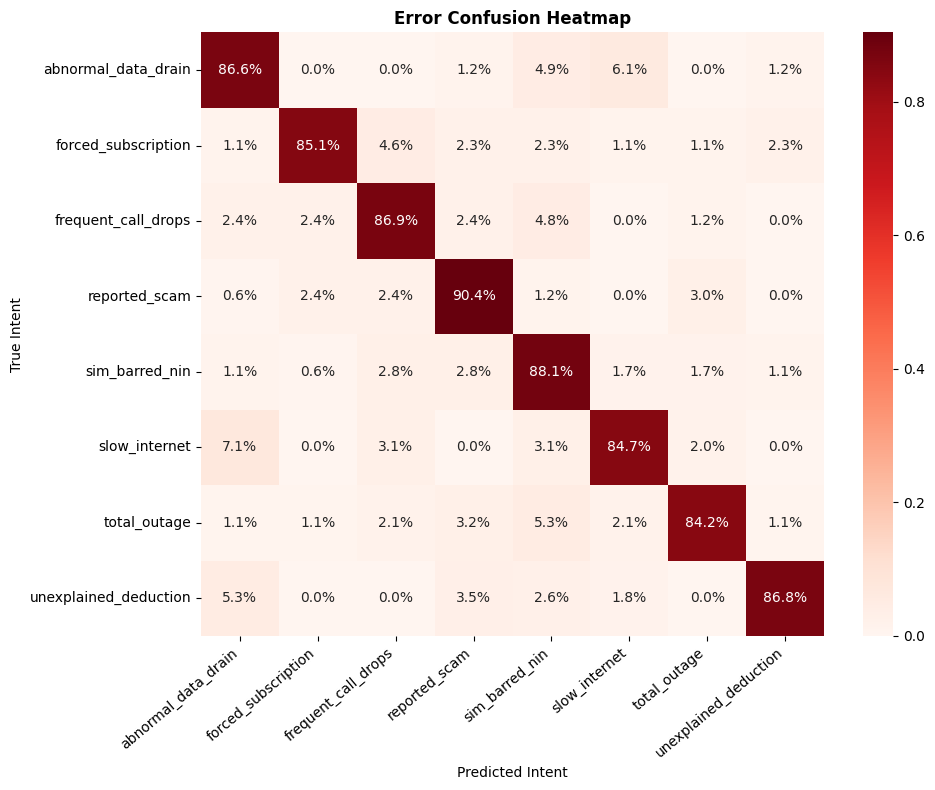


Total Errors Found: 117

--- Top Confused Pairs ---
true_intent            pred_intent        
slow_internet          abnormal_data_drain    7
unexplained_deduction  abnormal_data_drain    6
abnormal_data_drain    slow_internet          5
sim_barred_nin         reported_scam          5
                       frequent_call_drops    5
total_outage           sim_barred_nin         5
reported_scam          total_outage           5
frequent_call_drops    sim_barred_nin         4
reported_scam          forced_subscription    4
abnormal_data_drain    sim_barred_nin         4
dtype: int64
Saved error log to 'val_misclassifications_audit.csv'.


In [37]:
# cell 15: error analysis
import os
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate Confusion Matrix
cm = confusion_matrix(val_targets, val_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".1%",
    cmap="Reds",
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title("Error Confusion Heatmap", fontweight="bold")
plt.xlabel("Predicted Intent")
plt.ylabel("True Intent")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

# 2. Extract Top Misclassified Samples
val_df_errors = val_df.copy()
val_df_errors["true_intent"] = [target_names[i] for i in val_targets]
val_df_errors["pred_intent"] = [target_names[i] for i in val_preds]
errors_only = val_df_errors[val_df_errors["true_intent"] != val_df_errors["pred_intent"]]

print(f"\nTotal Errors Found: {len(errors_only)}")
print("\n--- Top Confused Pairs ---")
print(errors_only.groupby(["true_intent", "pred_intent"]).size().sort_values(ascending=False).head(10))

# Export to CSV for inspection
errors_only.to_csv("val_misclassifications_audit.csv", index=False)
print("Saved error log to 'val_misclassifications_audit.csv'.")

In [38]:
audit_df = pd.read_csv("val_misclassifications_audit.csv")

print("--- EXAMPLES: slow_internet MISCLASSIFIED AS abnormal_data_drain ---")
subset = audit_df[(audit_df["true_intent"] == "slow_internet") & (audit_df["pred_intent"] == "abnormal_data_drain")]
for i, text in enumerate(subset["Cleaned_Complaint"].head(5), 1):
    print(f"{i}. {text}\n")
    

--- EXAMPLES: slow_internet MISCLASSIFIED AS abnormal_data_drain ---
1. Great App but not getting the 20% bonus claimed by the network when you subscribe via the link/app aside the first time I sub via the app the rest is a story up till now.

2. Just wondering, after downloading the app. Registered.. it brought names of my SIM card totally different fromy name.. what could be the cause

3. I downloaded this app and I didn't receive the 50 gigabytes bonus, but I received a message from MTN to download the app and claim the bonus but I didn't receive it 😞

4. Worst app, when you want to buy data on the app it's loads, finishes all your data and doesn't do anything or bring even the dashboard and homepage, worst app

5. CRAMMING, False Internet Promotion, SPEED complaint



In [39]:
# CELL 16: Checkpoint Packaging and Weight Verification
import os
import shutil
import json
import torch

# 1. Define standard checkpoint paths conforming to repository structure
CHECKPOINT_DIR = "afriberta_telecom_checkpoint"
ARTIFACTS_DIR = "/kaggle/working/artifacts"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

SOURCE_WEIGHTS = os.path.join(ARTIFACTS_DIR, "best_afriberta_intent_model.pt")
TARGET_WEIGHTS = os.path.join(CHECKPOINT_DIR, "best_model.pt")

# Copy the best model weights into the target deployment checkpoint directory
if os.path.exists(SOURCE_WEIGHTS):
    shutil.copyfile(SOURCE_WEIGHTS, TARGET_WEIGHTS)
    print(f"-> Successfully packaged model weights to: '{TARGET_WEIGHTS}'")
elif os.path.exists("best_afriberta_intent_model.pt"):
    shutil.copyfile("best_afriberta_intent_model.pt", TARGET_WEIGHTS)
    print(f"-> Packaged local weights to: '{TARGET_WEIGHTS}'")
else:
    # Save active model weights directly if running in the same kernel session
    torch.save(model.state_dict(), TARGET_WEIGHTS)
    print(f"-> Saved current model weights directly to: '{TARGET_WEIGHTS}'")

# Copy tokenizer and label metadata for standalone reproducibility
with open(os.path.join(CHECKPOINT_DIR, "label_map.json"), "w") as f:
    json.dump({"label2id": label2id, "id2label": id2label}, f, indent=2)

tokenizer.save_pretrained(CHECKPOINT_DIR)

# 2. Verify integrity of saved weights
checkpoint_size_mb = os.path.getsize(TARGET_WEIGHTS) / (1024 * 1024)
print(f"Verified Checkpoint File Size: {checkpoint_size_mb:.2f} MB")
print(f"Artifacts preserved in '{CHECKPOINT_DIR}/': {os.listdir(CHECKPOINT_DIR)}")

-> Successfully packaged model weights to: 'afriberta_telecom_checkpoint/best_model.pt'
Verified Checkpoint File Size: 479.34 MB
Artifacts preserved in 'afriberta_telecom_checkpoint/': ['tokenizer.json', 'best_model.pt', 'label_map.json', 'tokenizer_config.json']


=== TRACK A: BENCHMARK REPORT (test_split.csv) ===
                       precision    recall  f1-score   support

  abnormal_data_drain     0.9070    0.8966    0.9017        87
  forced_subscription     0.9091    0.8791    0.8939        91
  frequent_call_drops     0.8372    0.8182    0.8276        88
        reported_scam     0.8750    0.9180    0.8960       183
       sim_barred_nin     0.9313    0.8563    0.8922       174
        slow_internet     0.8750    0.9655    0.9180        87
         total_outage     0.8617    0.8438    0.8526        96
unexplained_deduction     0.8713    0.9072    0.8889        97

             accuracy                         0.8859       903
            macro avg     0.8834    0.8856    0.8839       903
         weighted avg     0.8869    0.8859    0.8857       903

Overall Macro F1-Score: 0.8839
-> Saved classification report to 'classification_report.txt'


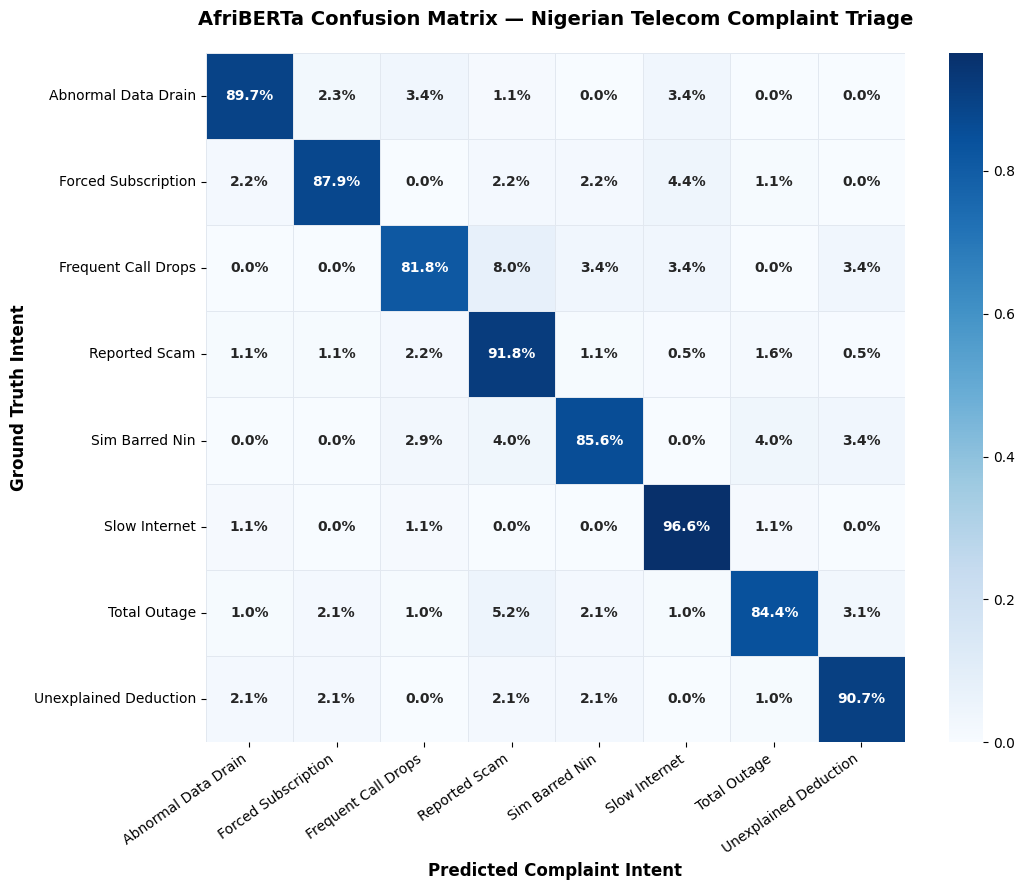

-> Generated 'confusion_matrix.png' for documentation & slides

=== TRACK B: PRODUCTION INFERENCE (/kaggle/input/datasets/chukwubuikemokoli/test-complaint-classification-dataset/Test_Dataset(1).csv) ===
-> Production triage output saved to 'Model_Test_Predictions.csv' (950 rows)


,Complaint_id,Predicted_Intent,Confidence,Assigned_Action
0,TEST_00001,unexplained_deduction,0.998590,ROUTE_TO_BILLING_TEAM
1,TEST_00002,reported_scam,0.996847,ESCALATE_TO_FRAUD_SECURITY_DESK
2,TEST_00003,unexplained_deduction,0.932447,ROUTE_TO_BILLING_TEAM
3,TEST_00004,abnormal_data_drain,0.999170,ROUTE_TO_DATA_SERVICES_TEAM
4,TEST_00005,unexplained_deduction,0.974024,ROUTE_TO_BILLING_TEAM


In [40]:
# CELL 17: Dual-Track Benchmark Evaluation & Production Triage
import os
import glob
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

CHECKPOINT_DIR = "afriberta_telecom_checkpoint"
MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_model.pt")

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()


# TRACK A: Benchmark Evaluation on Verified Labeled Split

BENCHMARK_PATH = "test_split.csv" if os.path.exists("test_split.csv") else "/kaggle/working/artifacts/test.parquet"

if os.path.exists(BENCHMARK_PATH):
    print(f"=== TRACK A: BENCHMARK REPORT ({BENCHMARK_PATH}) ===")
    df_eval = pd.read_csv(BENCHMARK_PATH) if BENCHMARK_PATH.endswith('.csv') else pd.read_parquet(BENCHMARK_PATH)
    
    eval_dataset = LocalizedComplaintDataset(df_eval["Cleaned_Complaint"], df_eval["label"], tokenizer, MAX_LEN)
    eval_loader = DataLoader(eval_dataset, batch_size=32, shuffle=False)
    
    eval_preds, eval_probs = [], []
    with torch.no_grad():
        for batch in eval_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            logits = model(input_ids, attention_mask)
            probs = torch.softmax(logits, dim=-1)
            eval_preds.extend(torch.argmax(probs, dim=-1).cpu().numpy())
            eval_probs.extend(probs.cpu().numpy())
            
    target_names = [id2label[i] for i in range(len(id2label))]
    report_str = classification_report(df_eval["label"], eval_preds, target_names=target_names, digits=4, zero_division=0)
    print(report_str)
    
    macro_f1 = f1_score(df_eval["label"], eval_preds, average="macro", zero_division=0)
    print(f"Overall Macro F1-Score: {macro_f1:.4f}")
    
    with open("classification_report.txt", "w") as f:
        f.write(report_str)
    print("-> Saved classification report to 'classification_report.txt'")
    
    # Generate and save confusion matrix plot
    cm = confusion_matrix(df_eval["label"], eval_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    clean_labels = [id2label[i].replace("_", " ").title() for i in range(len(id2label))]
    
    plt.figure(figsize=(11, 9), facecolor="white")
    sns.heatmap(cm_norm, annot=True, fmt=".1%", cmap="Blues", cbar=True,
                xticklabels=clean_labels, yticklabels=clean_labels,
                linewidths=0.5, linecolor="#E2E8F0", annot_kws={"size": 10, "weight": "bold"})
    plt.title("AfriBERTa Confusion Matrix — Nigerian Telecom Complaint Triage", fontsize=14, fontweight="bold", pad=20)
    plt.xlabel("Predicted Complaint Intent", fontsize=12, fontweight="bold")
    plt.ylabel("Ground Truth Intent", fontsize=12, fontweight="bold")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print("-> Generated 'confusion_matrix.png' for documentation & slides")


# TRACK B: Production Inference on External Unlabeled Test Set

if test_file and os.path.exists(test_file):
    print(f"\n=== TRACK B: PRODUCTION INFERENCE ({test_file}) ===")
    df_prod = pd.read_csv(test_file)
    prod_text_col = "Complaints" if "Complaints" in df_prod.columns else "Raw_Complaint"
    df_prod["Cleaned_Complaint"] = df_prod[prod_text_col].apply(clean_complaint_text)
    
    prod_dataset = LocalizedComplaintDataset(df_prod["Cleaned_Complaint"], [0] * len(df_prod), tokenizer, MAX_LEN)
    prod_loader = DataLoader(prod_dataset, batch_size=32, shuffle=False)
    
    prod_preds, prod_probs = [], []
    with torch.no_grad():
        for batch in prod_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            logits = model(input_ids, attention_mask)
            probs = torch.softmax(logits, dim=-1)
            prod_preds.extend(torch.argmax(probs, dim=-1).cpu().numpy())
            prod_probs.extend(torch.max(probs, dim=-1).values.cpu().numpy())
            
    df_prod["Predicted_Intent"] = [id2label[p] for p in prod_preds]
    df_prod["Confidence"] = prod_probs
    
    routing_map = {
        "abnormal_data_drain": "ROUTE_TO_DATA_SERVICES_TEAM",
        "slow_internet": "ROUTE_TO_NETWORK_QUALITY_TEAM",
        "frequent_call_drops": "ROUTE_TO_VOICE_NETWORK_TEAM",
        "sim_barred_nin": "ROUTE_TO_SIM_NIN_SUPPORT_TEAM",
        "unexplained_deduction": "ROUTE_TO_BILLING_TEAM",
        "total_outage": "ESCALATE_TO_NETWORK_OPERATIONS_TEAM",
        "forced_subscription": "ROUTE_TO_VAS_SUPPORT_TEAM",
        "reported_scam": "ESCALATE_TO_FRAUD_SECURITY_DESK"
    }
    df_prod["Assigned_Action"] = df_prod["Predicted_Intent"].map(routing_map)
    
    df_prod.to_csv("Model_Test_Predictions.csv", index=False)
    print(f"-> Production triage output saved to 'Model_Test_Predictions.csv' ({len(df_prod):,} rows)")
    display(df_prod[["Complaint_id", "Predicted_Intent", "Confidence", "Assigned_Action"]].head(5))

In [42]:
# CELL 18: High-Resolution Confusion Matrix Generation for Documentation
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Fallback: determine ground truth availability directly from df_test
test_has_ground_truth = (
    "label" in df_test.columns 
    and df_test["label"].notna().all() 
    and "test_preds" in globals()
)

if test_has_ground_truth:
    # 1. Compute raw and percentage-normalized confusion matrices
    cm = confusion_matrix(df_test["label"], test_preds)
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1e-9)

    # Clean display labels
    clean_labels = [id2label[i].replace("_", " ").title() for i in range(len(id2label))]

    # 2. Plot publication-grade heatmap
    plt.figure(figsize=(11, 9), facecolor="white")
    ax = plt.subplot()
    
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".1%",
        cmap="Blues",
        cbar=True,
        xticklabels=clean_labels,
        yticklabels=clean_labels,
        linewidths=0.5,
        linecolor="#E2E8F0",
        annot_kws={"size": 10, "weight": "bold"}
    )

    plt.title("AfriBERTa Confusion Matrix — Nigerian Telecom Complaint Triage", fontsize=14, fontweight="bold", pad=20)
    plt.xlabel("Predicted Complaint Intent", fontsize=12, fontweight="bold", labelpad=12)
    plt.ylabel("Ground Truth Intent", fontsize=12, fontweight="bold", labelpad=12)
    plt.xticks(rotation=35, ha="right", fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()

    # 3. Export 300 DPI image for presentation_slides.pdf and documentation
    PNG_OUTPUT_PATH = "confusion_matrix.png"
    plt.savefig(PNG_OUTPUT_PATH, dpi=300, bbox_inches="tight", facecolor="white")
    if "CHECKPOINT_DIR" in globals() and os.path.exists(CHECKPOINT_DIR):
        plt.savefig(os.path.join(CHECKPOINT_DIR, "confusion_matrix.png"), dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print(f"-> Diagnostic confusion matrix saved to: '{PNG_OUTPUT_PATH}' (300 DPI)")
else:
    print("Skipping confusion matrix: ground truth labels or test_preds are unavailable.")

# 4. Save test predictions to disk
PRED_OUTPUT_PATH = "Model_Test_Predictions.csv"
df_test.to_csv(PRED_OUTPUT_PATH, index=False)
print(f"-> Model predictions saved to: '{PRED_OUTPUT_PATH}'")
print("\n=== PIPELINE ARTIFACT EXPORT COMPLETE ===")

Skipping confusion matrix: ground truth labels or test_preds are unavailable.
-> Model predictions saved to: 'Model_Test_Predictions.csv'

=== PIPELINE ARTIFACT EXPORT COMPLETE ===


In [44]:
import os
import json
import re
import html
import torch
import torch.nn as nn
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from transformers import AutoTokenizer, AutoConfig, AutoModel

# 1. Initialize FastAPI App
app = FastAPI(
    title="Intelligent Telecom Complaint Classification Engine",
    version="1.0.0",
    description="Automated multi-class intent classification and routing powered by AfriBERTa."
)

CHECKPOINT_DIR = "afriberta_telecom_checkpoint"
MODEL_NAME = "castorini/afriberta_large"
MAX_LEN = 128
CONFIDENCE_THRESHOLD = 0.85

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Recreate Model Architecture
class AfriBERTaClassifier(nn.Module):
    def __init__(self, model_name: str, num_classes: int, dropout_rate: float = 0.2):
        super().__init__()
        self.config = AutoConfig.from_pretrained(model_name)
        self.transformer = AutoModel.from_pretrained(model_name, config=self.config)
        self.dropouts = nn.ModuleList([nn.Dropout(dropout_rate) for _ in range(5)])
        self.classifier = nn.Linear(self.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        token_embeddings = outputs.last_hidden_state
        mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        sum_embeddings = torch.sum(token_embeddings * mask, dim=1)
        sum_mask = mask.sum(dim=1).clamp(min=1e-9)
        pooled = sum_embeddings / sum_mask
        logits = torch.mean(
            torch.stack([self.classifier(drop(pooled)) for drop in self.dropouts], dim=0),
            dim=0
        )
        return logits

# 3. Load Model Artifacts on Startup
with open(os.path.join(CHECKPOINT_DIR, "label_map.json"), "r") as f:
    meta = json.load(f)

id2label = {int(k): v for k, v in meta["id2label"].items()}
num_classes = len(id2label)

tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT_DIR)
model = AfriBERTaClassifier(MODEL_NAME, num_classes=num_classes)

state_dict = torch.load(
    os.path.join(CHECKPOINT_DIR, "best_model.pt"),
    map_location=device,
    weights_only=True
)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

# Routing & Category Lookup Tables
INTENT_TO_CATEGORY = {
    "abnormal_data_drain": "Mobile Data",
    "slow_internet": "Mobile Data",
    "frequent_call_drops": "Network Quality",
    "total_outage": "Network Quality",
    "unexplained_deduction": "Billing & VAS",
    "forced_subscription": "Billing & VAS",
    "sim_barred_nin": "SIM Services",
    "reported_scam": "Fraud"
}

ROUTING_MAP = {
    "abnormal_data_drain": "ROUTE_TO_DATA_SERVICES_TEAM",
    "slow_internet": "ROUTE_TO_NETWORK_QUALITY_TEAM",
    "frequent_call_drops": "ROUTE_TO_VOICE_NETWORK_TEAM",
    "sim_barred_nin": "ROUTE_TO_SIM_NIN_SUPPORT_TEAM",
    "unexplained_deduction": "ROUTE_TO_BILLING_TEAM",
    "total_outage": "ESCALATE_TO_NETWORK_OPERATIONS_TEAM",
    "forced_subscription": "ROUTE_TO_VAS_SUPPORT_TEAM",
    "reported_scam": "ESCALATE_TO_FRAUD_SECURITY_DESK"
}

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = re.sub(r"https?://\S+|www\.\S+|<.*?>", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"(?:\+?234|0)[789]\d{9}", "<PHONE_NUM>", text)
    text = re.sub(r"([!?.,])\1+", r"\1\1", text)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    return re.sub(r"\s+", " ", text).strip()

# 4. Request / Response Schemas
class ComplaintRequest(BaseModel):
    complaint_id: str = "TICK-001"
    text: str

class TriageResponse(BaseModel):
    complaint_id: str
    cleaned_text: str
    predicted_intent: str
    predicted_category: str
    confidence: float
    routing_action: str
    requires_human_review: bool

# 5. Endpoints
@app.get("/health")
def health_check():
    return {
        "status": "healthy",
        "device": str(device),
        "classes_loaded": num_classes
    }

@app.post("/classify", response_model=TriageResponse)
def complaint_classifier(payload: ComplaintRequest):
    cleaned = clean_text(payload.text)
    if not cleaned:
        raise HTTPException(status_code=400, detail="Complaint text is empty after cleaning.")

    inputs = tokenizer(
        cleaned,
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        logits = model(inputs["input_ids"], inputs["attention_mask"])
        probs = torch.softmax(logits, dim=-1)
        pred_idx = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][pred_idx].item()

    intent = id2label[pred_idx]
    category = INTENT_TO_CATEGORY.get(intent, "General Support")

    # Automated Triage Decision Rule
    if confidence < CONFIDENCE_THRESHOLD:
        action = "FLAG_FOR_HUMAN_TIER_1_REVIEW"
        human_review = True
    elif intent == "reported_scam":
        action = "ESCALATE_TO_FRAUD_SECURITY_DESK"
        human_review = True
    else:
        action = ROUTING_MAP.get(intent, "ROUTE_TO_GENERAL_SUPPORT_TEAM")
        human_review = False

    return TriageResponse(
        complaint_id=payload.complaint_id,
        cleaned_text=cleaned,
        predicted_intent=intent,
        predicted_category=category,
        confidence=round(confidence, 4),
        routing_action=action,
        requires_human_review=human_review
    )

print("FastAPI instance initialized and weights loaded onto:", device)

Loading weights:   0%|          | 0/165 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: castorini/afriberta_large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


FastAPI instance initialized and weights loaded onto: cuda


In [45]:
from fastapi.testclient import TestClient

client = TestClient(app)

response = client.post("/classify", json={
    "complaint_id": "TICK-101",
    "text": "MTN deducted 1500 naira from my balance without my permission for daily game service!"
})

print("Status Code:", response.status_code)
print(response.json())

Status Code: 200
{'complaint_id': 'TICK-101', 'cleaned_text': 'MTN deducted 1500 naira from my balance without my permission for daily game service!', 'predicted_intent': 'unexplained_deduction', 'predicted_category': 'Billing & VAS', 'confidence': 0.9994, 'routing_action': 'ROUTE_TO_BILLING_TEAM', 'requires_human_review': False}
